# Exercise: Groupby, Hierarchical Indexing, and Data Merging

<div class="alert alert-block alert-warning">
<strong>Prerequisite:</strong> This exercise builds upon the concepts of the previous exercise. Please ensure you have completed the initial data cleaning exercise before proceeding.
</div>

In this notebook, we will move beyond single-table cleaning to what is essentially relational data analysis. You may notice some similarities in the concepts presented here with SQL. We will combine our song data (from the previous exercise) with artist metadata to uncover additional insights into genre performance and artist popularity.

---

# Import Libraries

In [1]:
import pandas as pd

# Recap: Building a Cleaning Pipeline

Before we introduce new data, let's consolidate the cleaning steps from the previous exercise into a single, efficient workflow. Your code should exist within a function named `clean_spotify_data()` that takes a file path as input and returns a cleaned DataFrame. The function itself should not print anything; you've already inspected the intermediary steps in the previous assignment and verified that it works. This should only return the cleaned DataFrame.

Using the original `spotify_songs_sample.csv` (same steps as previous assignment):
- Load the data and set `track_id` as the index.
- Convert `album_type` to a boolean.
- Handle missing values for `explicit`, `copies`, `album_name`, and `popularity`.
- Convert `artist_names` from a string representation to a Python list.

Note: For `popularity`, any of the three implementation methods you chose will work and does not matter for this exercise.

Assign the result of the `clean_spotify_data()` function to a DataFrame named `songs_df`.

In [2]:
def clean_spotify_songs(file_path: str) -> pd.DataFrame:
    # 1. Load the dataset
    df = pd.read_csv("spotify_songs_sample.csv", index_col="track_id")

    # 2. Update album_type to boolean (single = True, album = False)
    df["album_type"] = df["album_type"].map({"album": False, "single": True})

    # 3. Handle missing values:
    # Drop rows with missing 'explicit' values
    df = df.dropna(subset=["explicit"])

    # Fill missing 'copies' with the median
    df["copies"] = df["copies"].fillna(df["copies"].median())

    # Fill missing 'album_name' by matching album_id (relational fill)
    df["album_name"] = df.groupby("album_id")["album_name"].transform("first")

    # Split 'artist_names' into a list
    df["artist_names"] = df["artist_names"].str.split("|")

    # 4. Handle 'popularity' using neighborhood mean (sorted by rank)
    df = df.sort_values("rank")
    df["popularity"] = df["popularity"].interpolate().ffill().bfill()
    # Another possible solution:
    # df['popularity'] = df['popularity'].interpolate(limit_direction='both')

    return df


songs_df = clean_spotify_songs("spotify_songs_sample.csv")

# Display cleaned data
songs_df.head()

,rank,track_name,artist_names,album_name,album_id,popularity,duration,explicit,release_date,album_type,copies
track_id,,,,,,,,,,,
2plbrEY59IikOBgBGLjaoe,1,Die With A Smile,"[Lady Gaga, Bruno Mars]",Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0
3sK8wGT43QFpWrvNQsrQya,2,DtMF,[Bad Bunny],DeBÍ TiRAR MáS FOToS,5K79FLRUCSysQnVESLcTdb,98.0,3:57,1.0,2025-01-05,False,3.0
6dOtVTDdiauQNBQEDOtlAB,3,BIRDS OF A FEATHER,[Billie Eilish],HIT ME HARD AND SOFT,7aJuG4TFXa2hmE4z1yxc3n,98.0,3:30,0.0,2024-05-17,False,7.0
0zirWZTcXBBwGsevrsIpvT,4,Clean Baby Sleep White Noise (Loopable),"[Dream Supplier, Baby Sleeps, Background White...",Best White Noise For Sleeping Baby,0NGHR9zjS5eFFlqtClA9VV,97.0,2:22,0.0,2020-04-29,True,2.0
2lTm559tuIvatlT1u0JYG2,5,BAILE INoLVIDABLE,[Bad Bunny],DeBÍ TiRAR MáS FOToS,5K79FLRUCSysQnVESLcTdb,96.0,6:07,1.0,2025-01-05,False,4.0


# Expanding Our Scope: Artist Metadata

Currently, our dataset `songs_df` only contains the names of the artists. To perform a more granular analysis, such as comparing performance across different musical genres, we need more information.

We have provided a supplemental dataset, `spotify_artists_sample.csv`, which contains artist-level metrics like followers and genre tags.

**Task:** Load the artist dataset `artists_df` and set `artist_id` as the index. Inspect the first few rows to understand the structure of this metadata.

In [3]:
artists_df = pd.read_csv("spotify_artists_sample.csv", index_col="artist_id")
artists_df.head()

,name,followers,popularity,genres,main_genre
artist_id,,,,,
6Cqtx9fpxzggIMuKn0RGCp,Dream Supplier,13878,85,"sleep, white noise, rain, binaural, lullaby, c...","Easy Listening, Electronic, New Age, Rock"
2YZyLoL8N0Wb9xBt1NhZWg,Kendrick Lamar,45674032,91,"hip hop, west coast hip hop",Hip Hop
250b0Wlc5Vk0CoUsaCY84M,JENNIE,13013134,83,k-pop,Pop
6zO1dZ40fTZ5hY9NnnRJSk,yung kai,2117767,71,"k-pop, nyc pop, sped up, chill r&b, gen z sing...","Electronic, Pop, R&B, Rock"
4V8LLVI7PbaPR0K2TGSxFF,"Tyler, The Creator",25263506,88,"hip hop, rap",Hip Hop


## Validating the Artist Metadata

Before proceeding, we must ensure our supplemental data is clean. Inspect `artists_df` for missing or invalid values. If you find gaps in critical columns like `main_genre` or `followers`, resolve them appropriately based on the techniques we practiced in the previous exercise.

In [4]:
artists_df.info()

<class 'pandas.DataFrame'>
Index: 73 entries, 6Cqtx9fpxzggIMuKn0RGCp to 5NGO30tJxFlKixkPSgXcFE
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        73 non-null     str  
 1   followers   73 non-null     int64
 2   popularity  73 non-null     int64
 3   genres      73 non-null     str  
 4   main_genre  72 non-null     str  
dtypes: int64(2), str(3)
memory usage: 3.4+ KB


In [5]:
artists_df.isna().sum()

name          0
followers     0
popularity    0
genres        0
main_genre    1
dtype: int64

In [6]:
# Find the rows in artists_df where main_genre is NA
artists_df[artists_df["main_genre"].isna()]

,name,followers,popularity,genres,main_genre
artist_id,,,,,
48zEowASEXWsK6lgP1xotZ,Baby Sleeps,7737,28,native american music,NaN


In [7]:
# Fill na values in main_genre with the corresponding value in genres
artists_df["main_genre"] = artists_df["main_genre"].fillna(artists_df["genres"])
# Check that the na table is now empty
artists_df[artists_df["main_genre"].isna()]

,name,followers,popularity,genres,main_genre
artist_id,,,,,


## Merging Datasets

Now that both tables are prepared, we want to combine them using the artist's name as our "common factor." However, relational merging requires a precise match.

**Task:** Inspect the keys we intend to merge on: `artist_names` in our songs DataFrame and `name` in our artists DataFrame. Do you notice a structural difference between how artists are stored in these two tables?

In [8]:
songs_df["artist_names"], artists_df["name"]

(track_id
 2plbrEY59IikOBgBGLjaoe                              [Lady Gaga, Bruno Mars]
 3sK8wGT43QFpWrvNQsrQya                                          [Bad Bunny]
 6dOtVTDdiauQNBQEDOtlAB                                      [Billie Eilish]
 0zirWZTcXBBwGsevrsIpvT    [Dream Supplier, Baby Sleeps, Background White...
 2lTm559tuIvatlT1u0JYG2                                          [Bad Bunny]
                                                 ...                        
 4OLT65TRsOx3Iv1TlCcQVb    [Gabito Ballesteros, Natanael Cano, Luis R Con...
 7BqBn9nzAq8spo5e7cZ0dJ                                         [Bruno Mars]
 6iOndD4OFo7GkaDypWQIou                   [W Sound, Beéle, Ovy On The Drums]
 3t72JCbFJ3syOhFC7x9Pa4                                         [Neton Vega]
 4DnrAI8WyUY6gkOwl8GlPN                                    [Alleh, Yorghaki]
 Name: artist_names, Length: 95, dtype: object,
 artist_id
 6Cqtx9fpxzggIMuKn0RGCp        Dream Supplier
 2YZyLoL8N0Wb9xBt1NhZWg        Kendric

## Aligning Structural Differences

As you likely noticed, `artist_names` in our song data is a list (to account for collaborations), while `name` in the artist data is a single string. We cannot merge a **list** directly with a **string**.

Take a moment to investigate which method we would use to resolve this issue. Once you've thought about it, double-click to reveal the solution.

**[DOUBLE CLICK TO REVEAL SOLUTION]**

<!--
**Solution:** Use the `.explode()` method on the `artist_names` column. (read more: https://www.datacamp.com/tutorial/pandas-explode)

This operation creates a unique row for every artist in the list while duplicating the song's information (like `track_name` and `rank`). This "flattens" the data, making it compatible for a merge.

Save the results of the solution to `expl_songs_df`
-->

In [9]:
expl_songs_df = songs_df.explode("artist_names")
expl_songs_df.head()

,rank,track_name,artist_names,album_name,album_id,popularity,duration,explicit,release_date,album_type,copies
track_id,,,,,,,,,,,
2plbrEY59IikOBgBGLjaoe,1,Die With A Smile,Lady Gaga,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0
2plbrEY59IikOBgBGLjaoe,1,Die With A Smile,Bruno Mars,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0
3sK8wGT43QFpWrvNQsrQya,2,DtMF,Bad Bunny,DeBÍ TiRAR MáS FOToS,5K79FLRUCSysQnVESLcTdb,98.0,3:57,1.0,2025-01-05,False,3.0
6dOtVTDdiauQNBQEDOtlAB,3,BIRDS OF A FEATHER,Billie Eilish,HIT ME HARD AND SOFT,7aJuG4TFXa2hmE4z1yxc3n,98.0,3:30,0.0,2024-05-17,False,7.0
0zirWZTcXBBwGsevrsIpvT,4,Clean Baby Sleep White Noise (Loopable),Dream Supplier,Best White Noise For Sleeping Baby,0NGHR9zjS5eFFlqtClA9VV,97.0,2:22,0.0,2020-04-29,True,2.0


## Merging the DataFrames

With both DataFrames prepared, we can now perform the merge operation.

**Task:** Merge `expl_songs_df` with `artists_df` to create a new DataFrame named `song_art_df`. Note that the artist's name is stored in different column titles across the two sets.

_For the purposes of the participation question later on, ensure you set `expl_songs_df` as the **left** table, and `artists_df` as the **right** table._

In [10]:
song_art_df = pd.merge(
    expl_songs_df,
    artists_df,
    left_on="artist_names",
    right_on="name",
)
song_art_df.head()

,rank,track_name,artist_names,album_name,album_id,popularity_x,duration,explicit,release_date,album_type,copies,name,followers,popularity_y,genres,main_genre
0,1,Die With A Smile,Lady Gaga,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0,Lady Gaga,43713096,90,"art pop, pop",Pop
1,1,Die With A Smile,Bruno Mars,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0,Bruno Mars,77355363,92,"dance pop, pop",Pop
2,2,DtMF,Bad Bunny,DeBÍ TiRAR MáS FOToS,5K79FLRUCSysQnVESLcTdb,98.0,3:57,1.0,2025-01-05,False,3.0,Bad Bunny,105635803,99,"reggaeton, trap latino, urbano latino, latin",Latin
3,3,BIRDS OF A FEATHER,Billie Eilish,HIT ME HARD AND SOFT,7aJuG4TFXa2hmE4z1yxc3n,98.0,3:30,0.0,2024-05-17,False,7.0,Billie Eilish,121278701,93,"art pop, pop",Pop
4,4,Clean Baby Sleep White Noise (Loopable),Dream Supplier,Best White Noise For Sleeping Baby,0NGHR9zjS5eFFlqtClA9VV,97.0,2:22,0.0,2020-04-29,True,2.0,Dream Supplier,13878,85,"sleep, white noise, rain, binaural, lullaby, c...","Easy Listening, Electronic, New Age, Rock"


## Inspect the Merged DataFrame

Verify that the merge was successful by inspecting the first few rows of the resulting DataFrame. Ensure that artist-level information like `main_genre` and `followers` are now included alongside song-level data. You should also check the columns to confirm that no unintended duplicates or missing values were introduced during the merge.

**TASK:** There is information that is now missing from the merged DataFrame that was present in the original `songs_df` and `artists_df`. Identify it.

**[DOUBLE CLICK FOR HINT]**

<!--
Hint: inspect `df.index.names` and `df.columns`.
Consider whether key identifiers are stored as *index names* or as *columns*, and whether the merge created additional columns.
-->

In [11]:
# Visually inspect the three dataframes.

print(f'columns: {songs_df.columns}, index: {songs_df.index.name}')
print(f"columns: {artists_df.columns}, index: {artists_df.index.name}")
print(f"columns: {song_art_df.columns}, index: {song_art_df.index.name}")

columns: Index(['rank', 'track_name', 'artist_names', 'album_name', 'album_id',
       'popularity', 'duration', 'explicit', 'release_date', 'album_type',
       'copies'],
      dtype='str'), index: track_id
columns: Index(['name', 'followers', 'popularity', 'genres', 'main_genre'], dtype='str'), index: artist_id
columns: Index(['rank', 'track_name', 'artist_names', 'album_name', 'album_id',
       'popularity_x', 'duration', 'explicit', 'release_date', 'album_type',
       'copies', 'name', 'followers', 'popularity_y', 'genres', 'main_genre'],
      dtype='str'), index: None


In [12]:
# This is a more advanced implementation using set theory to find the difference.

# set of column labels and the index name from `songs_df`
A = set([songs_df.index.name]) | set(songs_df.columns)

# set of column labels and the index name from `artists_df`
B = set([artists_df.index.name]) | set(artists_df.columns)

# set of column labels present in the merged `song_art_df` (no index specified, so we ignore it)
C = set(song_art_df.columns)

# Result: labels that appeared as a column or index-name in either original but are missing from merged columns
# all elements in A and B, with any elements in C removed.
print(f"missing columns: {(A | B) - C}")

missing columns: {'popularity', 'artist_id', 'track_id'}


***
<div style="margin-top:10rem;">
<div class="alert alert-block alert-warning">
<strong>Look-Ahead Warning:</strong> To get the most out of this exercise, please avoid viewing the section below before completing the cell above!
</div>
<div style="width:5rem;height:5rem;margin:auto">

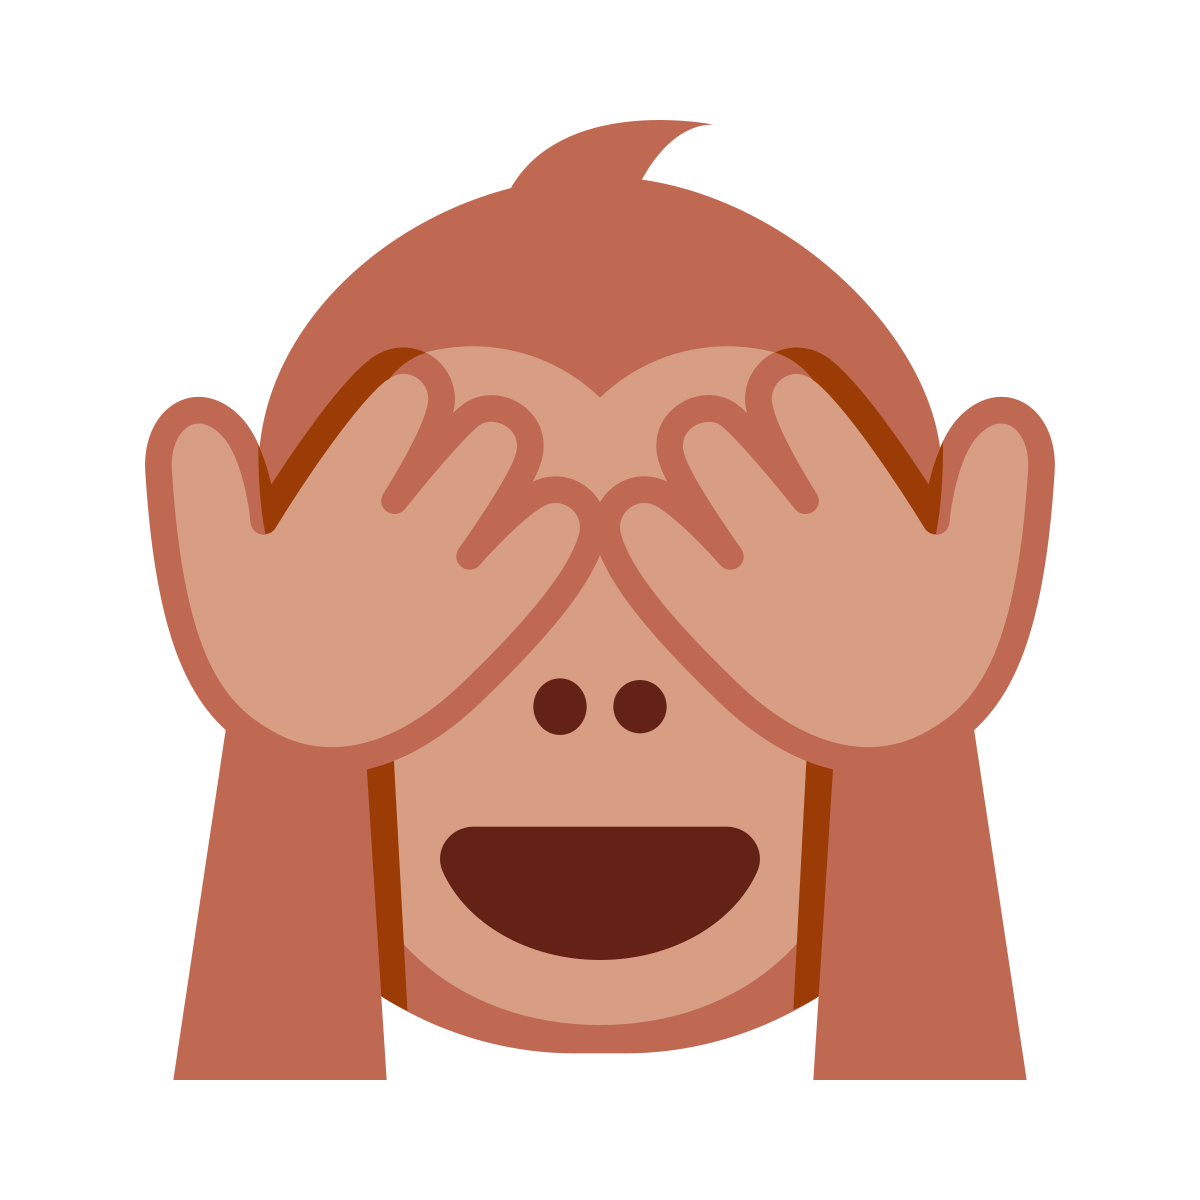

</div>

<div style="margin-top:10rem;">

***

## Preserving Identifiers

You should have correctly identified that the missing columns are: `track_id`, `artists_id`, and `popularity`, and that there are two new columns: `popularity_x` and `popularity_y`. We will focus on the first two missing columns for now: `track_id`, `artists_id`.

**Problem:** By default, `pd.merge()` focuses on combining **columns**. If your unique identifiers are currently set as the **index**, they won't be included in the new DataFrame's columns, and you'll lose that metadata in the final result.

**Task:** Take a moment to investigate which method we would use to resolve this issue. Then, update `song_art_df` with the corrected code.

**[DOUBLE CLICK TO REVEAL HINT]**

<!--
Hint: Think about a method that does the exact opposite of `df.set_index()`.
-->

In [13]:
# Create a temporary copy "temp" to reset the index without modifying the original "expl_songs_df".
# This preserves the original index-based structure for later use. We are just testing the result here.
temp = expl_songs_df.reset_index()
temp.head()  # notice that track_id is no longer an index, and we are back to `0, 1, 2...`

,track_id,rank,track_name,artist_names,album_name,album_id,popularity,duration,explicit,release_date,album_type,copies
0,2plbrEY59IikOBgBGLjaoe,1,Die With A Smile,Lady Gaga,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0
1,2plbrEY59IikOBgBGLjaoe,1,Die With A Smile,Bruno Mars,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0
2,3sK8wGT43QFpWrvNQsrQya,2,DtMF,Bad Bunny,DeBÍ TiRAR MáS FOToS,5K79FLRUCSysQnVESLcTdb,98.0,3:57,1.0,2025-01-05,False,3.0
3,6dOtVTDdiauQNBQEDOtlAB,3,BIRDS OF A FEATHER,Billie Eilish,HIT ME HARD AND SOFT,7aJuG4TFXa2hmE4z1yxc3n,98.0,3:30,0.0,2024-05-17,False,7.0
4,0zirWZTcXBBwGsevrsIpvT,4,Clean Baby Sleep White Noise (Loopable),Dream Supplier,Best White Noise For Sleeping Baby,0NGHR9zjS5eFFlqtClA9VV,97.0,2:22,0.0,2020-04-29,True,2.0


In [14]:
song_art_df = pd.merge(
    expl_songs_df.reset_index(),
    artists_df.reset_index(),
    left_on="artist_names",
    right_on="name",
)
song_art_df.head()

,track_id,rank,track_name,artist_names,album_name,album_id,popularity_x,duration,explicit,release_date,album_type,copies,artist_id,name,followers,popularity_y,genres,main_genre
0,2plbrEY59IikOBgBGLjaoe,1,Die With A Smile,Lady Gaga,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0,1HY2Jd0NmPuamShAr6KMms,Lady Gaga,43713096,90,"art pop, pop",Pop
1,2plbrEY59IikOBgBGLjaoe,1,Die With A Smile,Bruno Mars,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,100.0,4:11,0.0,2024-08-16,True,9.0,0du5cEVh5yTK9QJze8zA0C,Bruno Mars,77355363,92,"dance pop, pop",Pop
2,3sK8wGT43QFpWrvNQsrQya,2,DtMF,Bad Bunny,DeBÍ TiRAR MáS FOToS,5K79FLRUCSysQnVESLcTdb,98.0,3:57,1.0,2025-01-05,False,3.0,4q3ewBCX7sLwd24euuV69X,Bad Bunny,105635803,99,"reggaeton, trap latino, urbano latino, latin",Latin
3,6dOtVTDdiauQNBQEDOtlAB,3,BIRDS OF A FEATHER,Billie Eilish,HIT ME HARD AND SOFT,7aJuG4TFXa2hmE4z1yxc3n,98.0,3:30,0.0,2024-05-17,False,7.0,6qqNVTkY8uBg9cP3Jd7DAH,Billie Eilish,121278701,93,"art pop, pop",Pop
4,0zirWZTcXBBwGsevrsIpvT,4,Clean Baby Sleep White Noise (Loopable),Dream Supplier,Best White Noise For Sleeping Baby,0NGHR9zjS5eFFlqtClA9VV,97.0,2:22,0.0,2020-04-29,True,2.0,6Cqtx9fpxzggIMuKn0RGCp,Dream Supplier,13878,85,"sleep, white noise, rain, binaural, lullaby, c...","Easy Listening, Electronic, New Age, Rock"


## Resolving Column Ambiguity

**Problem:** When you merge two DataFrames that share a common column name (like `popularity`), pandas cannot keep both under the same name. To prevent data loss, it automatically appends suffixes (`_x`, `_y`) to the merged column names.

While this prevents an error, it creates a "black box" for anyone reading your data. Without checking the original files, you don't know which score represents the track and which represents the artist.

**Task:** Inspect the values in `song_art_df` for an artist with multiple songs (e.g., `Kendrick Lamar`).
- Observe how the values in `popularity_x` behave compared to `popularity_y` across different rows.
- Based on your observations, deduce which column represents the song-level popularity and which represents the artist's overall popularity.

In [15]:
# Filter for Kendrick Lamar
kendrick_df = song_art_df[song_art_df['name'] == 'Kendrick Lamar']

# Observe the popularity_x and popularity_y columns
print(kendrick_df[['track_name', 'popularity_x', 'popularity_y']].head(10))

                          track_name  popularity_x  popularity_y
8                        Not Like Us          96.0            91
12          All The Stars (with SZA)          95.0            91
16                 luther (with sza)          94.0            91
18      tv off (feat. lefty gunplay)          94.0            91
51                       squabble up          91.0            91
103                          HUMBLE.          89.0            91
115  30 For 30 (with Kendrick Lamar)          89.0            91


## Analysis with Hierarchical Indexing (MultiIndex)

With our data finally combined and our IDs preserved, we can now answer complex questions.

**Task:** Create a MultiIndex, `genre_artist_stats_df`, by grouping your merged DataFrame by `main_genre` and artist `name`. 

Then, aggregate the following:
- Average song popularity per artist (within each genre). [careful; notice the popularity column!]
- Total copies sold per artist (within each genre).
- Count of unique tracks per artist (within each genre).

You may want to rename the columns either during or after the aggregation.

In [16]:
# Groupby with Hierarchical Indexing; Rename columns within agg() call
genre_artist_stats_df = song_art_df.groupby(["main_genre", "name"]).agg(
    avg_song_pop=("popularity_x", "mean"),
    total_copies_sold=("copies", "sum"),
    unique_track_count=("track_id", "count"),
)

genre_artist_stats_df.head(10)

avg_song_pop  \
main_genre                                name                           
Easy Listening, Electronic, New Age, Rock Dream Supplier     97.000000   
Electronic                                Daft Punk          89.000000   
                                          NOTION             90.000000   
Electronic, Pop, R&B                      Teddy Swims        91.000000   
                                          bees & honey       89.000000   
Electronic, Pop, R&B, Rock                yung kai           92.000000   
Folk, Rock                                Lord Huron         90.000000   
Hip Hop                                   Don Toliver        89.000000   
                                          Drake              91.000000   
                                          Kendrick Lamar     92.571429   

                                                          total_copies_sold  \
main_genre                                name                                
Easy Listening, Electronic, New Age, Rock Dream Supplier                2.0   
Electronic                                Daft Punk                   249.0   
                                          NOTION                       19.0   
Electronic, Pop, R&B                      Teddy Swims                2206.0   
                                          bees & honey                  4.0   
Electronic, Pop, R&B, Rock                yung kai                      3.0   
Folk, Rock                                Lord Huron                   20.0   
Hip Hop                                   Don Toliver                 182.0   
                                          Drake                         1.0   
                                          Kendrick Lamar               38.0   

                                                          unique_track_count  
main_genre                                name                                
Easy Listening, Electronic, New Age, Rock Dream Supplier                   1  
Electronic                                Daft Punk                        1  
                                          NOTION                           1  
Electronic, Pop, R&B                      Teddy Swims                      1  
                                          bees & honey                     1  
Electronic, Pop, R&B, Rock                yung kai                         1  
Folk, Rock                                Lord Huron                       1  
Hip Hop                                   Don Toliver                      1  
                                          Drake                            1  
                                          Kendrick Lamar                   7

In [17]:
# Groupby with Hierarchical Indexing; Rename columns afterwards
genre_artist_stats_df = song_art_df.groupby(["main_genre", "name"]).agg(
    {"popularity_x": "mean", "copies": "sum", "track_id": "count"}
)

genre_artist_stats_df.rename(
    columns={
        "popularity_x": "avg_song_pop",
        "copies": "total_copies_sold",
        "track_id": "unique_track_count",
    },
    inplace=True,
)
genre_artist_stats_df.head(10)

avg_song_pop  \
main_genre                                name                           
Easy Listening, Electronic, New Age, Rock Dream Supplier     97.000000   
Electronic                                Daft Punk          89.000000   
                                          NOTION             90.000000   
Electronic, Pop, R&B                      Teddy Swims        91.000000   
                                          bees & honey       89.000000   
Electronic, Pop, R&B, Rock                yung kai           92.000000   
Folk, Rock                                Lord Huron         90.000000   
Hip Hop                                   Don Toliver        89.000000   
                                          Drake              91.000000   
                                          Kendrick Lamar     92.571429   

                                                          total_copies_sold  \
main_genre                                name                                
Easy Listening, Electronic, New Age, Rock Dream Supplier                2.0   
Electronic                                Daft Punk                   249.0   
                                          NOTION                       19.0   
Electronic, Pop, R&B                      Teddy Swims                2206.0   
                                          bees & honey                  4.0   
Electronic, Pop, R&B, Rock                yung kai                      3.0   
Folk, Rock                                Lord Huron                   20.0   
Hip Hop                                   Don Toliver                 182.0   
                                          Drake                         1.0   
                                          Kendrick Lamar               38.0   

                                                          unique_track_count  
main_genre                                name                                
Easy Listening, Electronic, New Age, Rock Dream Supplier                   1  
Electronic                                Daft Punk                        1  
                                          NOTION                           1  
Electronic, Pop, R&B                      Teddy Swims                      1  
                                          bees & honey                     1  
Electronic, Pop, R&B, Rock                yung kai                         1  
Folk, Rock                                Lord Huron                       1  
Hip Hop                                   Don Toliver                      1  
                                          Drake                            1  
                                          Kendrick Lamar                   7

In [18]:
# We can also double-check that this is a MultiIndex.
print("Index names:", genre_artist_stats_df.index.names)
print(type(genre_artist_stats_df.index))

Index names: ['main_genre', 'name']
<class 'pandas.MultiIndex'>


Sort the resulting `genre_artist_stats_df` into a new DataFrame called `stats_sorted_df`. Ensure that:
- Genres are ordered alphabetically (A-Z)
- Artists within each genre are ranked by their average popularity in descending order.

In [19]:
# Sorting: Genre alphabetically (True), Artist popularity descending (False)
stats_sorted_df = genre_artist_stats_df.sort_values(
    by=["main_genre", "avg_song_pop"], ascending=[True, False]
)
stats_sorted_df.head(10)

avg_song_pop  \
main_genre                                name                           
Easy Listening, Electronic, New Age, Rock Dream Supplier     97.000000   
Electronic                                NOTION             90.000000   
                                          Daft Punk          89.000000   
Electronic, Pop, R&B                      Teddy Swims        91.000000   
                                          bees & honey       89.000000   
Electronic, Pop, R&B, Rock                yung kai           92.000000   
Folk, Rock                                Lord Huron         90.000000   
Hip Hop                                   Lefty Gunplay      94.000000   
                                          Kendrick Lamar     92.571429   
                                          Playboi Carti      92.000000   

                                                          total_copies_sold  \
main_genre                                name                                
Easy Listening, Electronic, New Age, Rock Dream Supplier                2.0   
Electronic                                NOTION                       19.0   
                                          Daft Punk                   249.0   
Electronic, Pop, R&B                      Teddy Swims                2206.0   
                                          bees & honey                  4.0   
Electronic, Pop, R&B, Rock                yung kai                      3.0   
Folk, Rock                                Lord Huron                   20.0   
Hip Hop                                   Lefty Gunplay                 1.0   
                                          Kendrick Lamar               38.0   
                                          Playboi Carti                 8.0   

                                                          unique_track_count  
main_genre                                name                                
Easy Listening, Electronic, New Age, Rock Dream Supplier                   1  
Electronic                                NOTION                           1  
                                          Daft Punk                        1  
Electronic, Pop, R&B                      Teddy Swims                      1  
                                          bees & honey                     1  
Electronic, Pop, R&B, Rock                yung kai                         1  
Folk, Rock                                Lord Huron                       1  
Hip Hop                                   Lefty Gunplay                    1  
                                          Kendrick Lamar                   7  
                                          Playboi Carti                    3

Suppose a stakeholder only cares about the `Pop` market. Slice your `stats_sorted_df` to return a DataFrame containing only the artists in the `Pop` genre. Ensure your result maintains the popularity rankings you calculated in the previous step.

In [20]:
stats_sorted_df.loc["Pop"]  # Shows only Pop artists

,avg_song_pop,total_copies_sold,unique_track_count
name,,,
Lady Gaga,96.500000,13.0,2
Gigi Perez,95.000000,4.0,1
ROSÉ,95.000000,1160.0,1
Billie Eilish,94.333333,12.0,3
Alex Warren,94.000000,738.0,1
Gracie Abrams,93.000000,8.0,2
JENNIE,92.500000,40.0,2
Lily-Rose Depp,92.000000,35.0,1
Bruno Mars,91.833333,4958.0,6


Suppose a stakeholder wants to zoom in on `Bruno Mars` specifically within the `Pop` genre. 

**Note:** You are not allowed to chain multiple `.loc` accessors to arrive at your result.

In [21]:
stats_sorted_df.loc[("Pop", "Bruno Mars")]

avg_song_pop            91.833333
total_copies_sold     4958.000000
unique_track_count       6.000000
Name: (Pop, Bruno Mars), dtype: float64

## Participation

<div style="background-color: #ffffcc; padding: 15px; border-left: 5px solid #ffd700; color: #333;"> 
    <strong>Post your replies to the following two questions in Slack #ics604-applied-data.</strong> </br>
    Please be sure to prefix your reply with "Exercise 2/4/2026" so we don't misrecord your participation.
</div>

1. In the 'Aligning Structural Differences' section, we use `.explode()` to flatten our artist lists. However, this operation introduces a significant structural issue. Inspect the resulting DataFrame `expl_songs_df`: 
    - What has changed about your row count and specific song entries?
    - What are the potential dangers of directly performing a `.sum()` or `.mean()` on this new DataFrame?

2. After merging, you noticed that `popularity_x` and `popularity_y` replaced the original `popularity` columns.
    - Based on your merge order (left vs. right), which one belongs to the song and which belongs to the artist?
    - Why would using the `popularity_y` in a groupby mean calculation give you a misleading result for an artist's "average performance"?
    - What is one specific way you could have handled the columns (either before, during, or after the merge call) to prevent this `_x`/`_y` confusion entirely?